# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-8: Algoritmo de Deutsch-Jozsa (Qiskit)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-8.  
Implementación equivalente en Qiskit del notebook Cirq `06_deutsch_jozsa.ipynb`.

### Problema que resuelve

Dado un oráculo que implementa una función $f: \{0,1\}^n \rightarrow \{0,1\}$, determinar si $f$ es:
- **Constante:** devuelve siempre 0 o siempre 1 para cualquier entrada
- **Balanceada:** devuelve 0 exactamente para la mitad de las entradas y 1 para la otra mitad

Clásicamente se necesitan hasta $2^{n-1} + 1$ consultas al oráculo en el peor caso.  
Deutsch-Jozsa lo resuelve con **una sola consulta** al oráculo cuántico.

### Pasos del algoritmo

| Paso | Acción | Estado resultante |
|---|---|---|
| 0 | Inicializar $n$ qubits de entrada + 1 qubit objetivo | $\vert 0\rangle^{\otimes n}\vert 0\rangle$ |
| 1 | H en cada qubit de entrada → superposición uniforme | $\frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} \vert x\rangle \vert 0\rangle$ |
| 2 | X + H en qubit objetivo → estado $\vert -\rangle$ | $\frac{1}{\sqrt{2^n}} \sum_x \vert x\rangle \vert -\rangle$ |
| 3 | Oracle $U_f$ → **phase kickback**: la fase $(-1)^{f(x)}$ pasa a los qubits de entrada | $\frac{1}{\sqrt{2^n}} \sum_x (-1)^{f(x)} \vert x\rangle \vert -\rangle$ |
| 4 | H en cada qubit de entrada → interferencia | $\sum_z \left(\sum_x (-1)^{f(x)+x\cdot z}\right) \vert z\rangle$ |
| 5 | Medir qubits de entrada | Si $f$ es **constante** → siempre $\vert 00\rangle$; si es **balanceada** → nunca $\vert 00\rangle$ |

### Implementación: domain_size = 4 → 2 qubits de entrada + 1 objetivo

**Función balanceada implementada:** $f(x_0, x_1) = x_0 \oplus x_1$ (XOR):

| Estado | $f(x)$ |
|:---:|:---:|
| $\vert 00\rangle$ | 0 |
| $\vert 01\rangle$ | 1 |
| $\vert 10\rangle$ | 1 |
| $\vert 11\rangle$ | 0 |

**Función constante implementada:** $f(x) = 0$ → oráculo = identidad.

### Diferencias de API respecto al libro (Qiskit 1.0+)

| Libro (API antigua) | Este notebook (Qiskit ≥1.0) |
|---|---|
| `from qiskit import execute, Aer` | `from qiskit_aer import AerSimulator` |
| `Aer.get_backend('qasm_simulator')` | `AerSimulator()` |
| `execute(circuit, simulator, shots=n)` | `simulator.run(transpile(circuit, simulator), shots=n)` |

### Oráculo

El oráculo representa la función $f$ como caja negra. Deutsch-Jozsa determina si es balanceada o constante consultándolo **una sola vez** — sin importar cuántos qubits tenga el registro de entrada.

En Qiskit el circuito tiene 3 qubits y 2 bits clásicos:
- `q[0]`, `q[1]` — qubits de entrada (registro de datos)
- `q[2]` — qubit objetivo (ancilla), inicializado en $|-\rangle$
- `c[0]`, `c[1]` — bits clásicos para almacenar la medición de los qubits de entrada

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


def oracle(circuit, data_qubits, y_qubit, is_balanced=True):
    """
    Aplica el oráculo U_f al circuito.

    Función balanceada f(x0, x1) = x0 XOR x1:
      - CX(data[0] → y): y ← y XOR x0
      - CX(data[1] → y): y ← y XOR x0 XOR x1
      Resultado neto: y XOR f(x), que implementa el phase kickback.

    Función constante f(x) = 0:
      - Identidad: no se aplica ninguna puerta.
      - El qubit objetivo y_qubit queda inalterado (en estado |-⟩).
    """
    if is_balanced:
        # Implementa f(x0, x1) = x0 ⊕ x1 mediante dos CX sucesivos
        circuit.cx(data_qubits[0], y_qubit)  # y ← y XOR x0
        circuit.cx(data_qubits[1], y_qubit)  # y ← y XOR x0 XOR x1
    # Si is_balanced=False: oráculo = identidad → f(x) = 0 constante
    return circuit

### Algoritmo principal

La función retorna el circuito y los conteos para poder visualizarlos por separado en el notebook.

In [2]:
def deutsch_jozsa(domain_size: int,
                  func_type_to_simulate: str = 'balanced',
                  shots: int = 1000):
    """
    Implementa el algoritmo de Deutsch-Jozsa.

    domain_size:            número de entradas de la función (debe ser potencia de 2)
    func_type_to_simulate:  'balanced' para función balanceada, cualquier otro valor para constante
    shots:                  repeticiones de la simulación

    Retorna: (circuit, counts)
    """
    # Número de qubits de entrada: n = log2(domain_size)
    # Para domain_size=4 → n=2 qubits de entrada + 1 qubit objetivo
    n = int(np.ceil(np.log2(domain_size)))

    # n qubits de entrada + 1 qubit objetivo, n bits clásicos para medir la entrada
    circuit = QuantumCircuit(n + 1, n)

    data_qubits = list(range(n))   # q[0], q[1]: registro de datos
    y_qubit = n                    # q[2]: qubit objetivo

    # Paso 1: H en cada qubit de entrada → superposición uniforme |+⟩^⊗n
    for q in data_qubits:
        circuit.h(q)

    # Paso 2: preparar qubit objetivo en |-⟩ = H|1⟩
    # X transforma |0⟩ → |1⟩, luego H transforma |1⟩ → |-⟩
    circuit.x(y_qubit)
    circuit.h(y_qubit)

    circuit.barrier()

    # Paso 3: consulta al oráculo U_f
    # El phase kickback codifica (-1)^f(x) en la fase de los qubits de entrada
    is_balanced = (func_type_to_simulate == 'balanced')
    circuit = oracle(circuit, data_qubits, y_qubit, is_balanced=is_balanced)

    circuit.barrier()

    # Paso 4: H en cada qubit de entrada → interferencia
    # Constructiva en |00⟩ si f es constante; destructiva si f es balanceada
    for q in data_qubits:
        circuit.h(q)

    # Paso 5: medir solo los qubits de entrada (el objetivo no importa)
    circuit.measure(data_qubits, list(range(n)))

    simulator = AerSimulator()
    counts = simulator.run(transpile(circuit, simulator), shots=shots).result().get_counts()

    return circuit, counts

---
## Caso 1: función balanceada $f(x_0, x_1) = x_0 \oplus x_1$

**Predicción:** tras la interferencia, la amplitud del estado $|00\rangle$ es cero. Nunca mediremos $|00\rangle$.  
El único estado observado será $|11\rangle$, confirmando que la función es balanceada.

> **Nota sobre el orden de bits en Qiskit:** el resultado se muestra como `c[n-1]...c[1]c[0]`, de modo que `'11'` significa $q[1]=1, q[0]=1$, es decir, el estado $|11\rangle$.

In [3]:
circuit_bal, counts_bal = deutsch_jozsa(domain_size=4,
                                        func_type_to_simulate='balanced',
                                        shots=1000)
print(circuit_bal.draw(output='text'))

     ┌───┐      ░            ░ ┌───┐┌─┐   
q_0: ┤ H ├──────░───■────────░─┤ H ├┤M├───
     ├───┤      ░   │        ░ ├───┤└╥┘┌─┐
q_1: ┤ H ├──────░───┼────■───░─┤ H ├─╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐ ░ └───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├─░─┤ X ├┤ X ├─░───────╫──╫─
     └───┘└───┘ ░ └───┘└───┘ ░       ║  ║ 
c: 2/════════════════════════════════╩══╩═
                                     0  1 


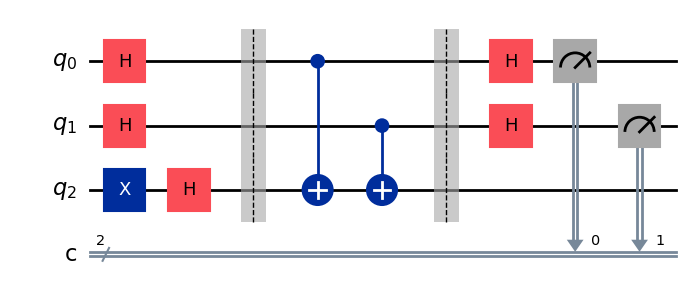

In [4]:
circuit_bal.draw('mpl')

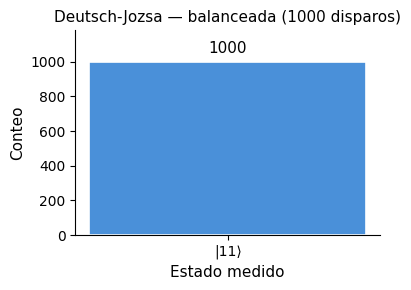

In [5]:
from qml_santanu.common.plot_utils import plot_counts

plot_counts(counts_bal, title='Deutsch-Jozsa — balanceada')

**Interpretación:** todas las mediciones dan $|11\rangle$. El estado $|00\rangle$ **nunca aparece** → la función es **balanceada**.

---
## Caso 2: función constante $f(x) = 0$

**Predicción:** sin oracle (identidad), la interferencia es completamente constructiva en $|00\rangle$.  
Todas las mediciones darán $|00\rangle$, confirmando que la función es constante.

In [6]:
circuit_const, counts_const = deutsch_jozsa(domain_size=4,
                                             func_type_to_simulate='constant',
                                             shots=1000)
print(circuit_const.draw(output='text'))

     ┌───┐      ░  ░ ┌───┐┌─┐   
q_0: ┤ H ├──────░──░─┤ H ├┤M├───
     ├───┤      ░  ░ ├───┤└╥┘┌─┐
q_1: ┤ H ├──────░──░─┤ H ├─╫─┤M├
     ├───┤┌───┐ ░  ░ └───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├─░──░───────╫──╫─
     └───┘└───┘ ░  ░       ║  ║ 
c: 2/══════════════════════╩══╩═
                           0  1 


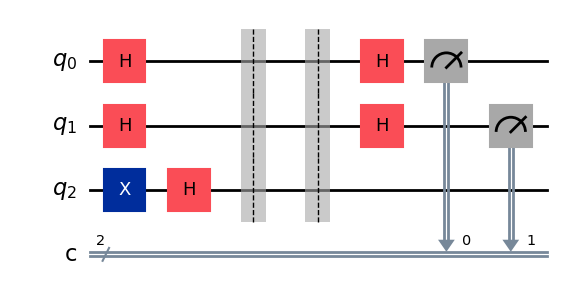

In [7]:
circuit_const.draw('mpl')

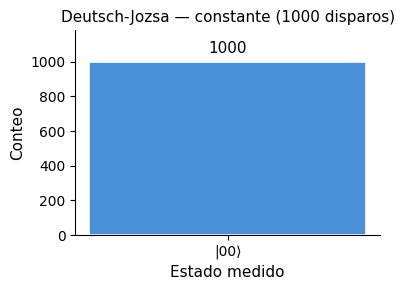

In [8]:
plot_counts(counts_const, title='Deutsch-Jozsa — constante')

**Interpretación:** todas las mediciones dan $|00\rangle$. El estado $|00\rangle$ **aparece siempre** → la función es **constante**.

---
## Resumen: regla de decisión

| Resultado de la medición | Conclusión |
|:---:|:---:|
| Siempre $\|00\rangle$ | Función **constante** |
| Nunca $\|00\rangle$ | Función **balanceada** |

Con una sola ejecución del circuito cuántico se obtiene la respuesta determinista, frente a las $2^{n-1}+1$ consultas que requiere el algoritmo clásico en el peor caso.